# Lesson 7: Visualization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')

In [15]:
df = pd.read_csv("Data\california_cities.csv")
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [16]:
df.isnull().sum()

Unnamed: 0             0
city                   0
latd                   0
longd                  0
elevation_m           48
elevation_ft          12
population_total       0
area_total_sq_mi       2
area_land_sq_mi        0
area_water_sq_mi       1
area_total_km2         5
area_land_km2          4
area_water_km2         4
area_water_percent     5
dtype: int64

In [17]:
df.dropna(inplace=True)

In [18]:
df.isnull().sum()

Unnamed: 0            0
city                  0
latd                  0
longd                 0
elevation_m           0
elevation_ft          0
population_total      0
area_total_sq_mi      0
area_land_sq_mi       0
area_water_sq_mi      0
area_total_km2        0
area_land_km2         0
area_water_km2        0
area_water_percent    0
dtype: int64

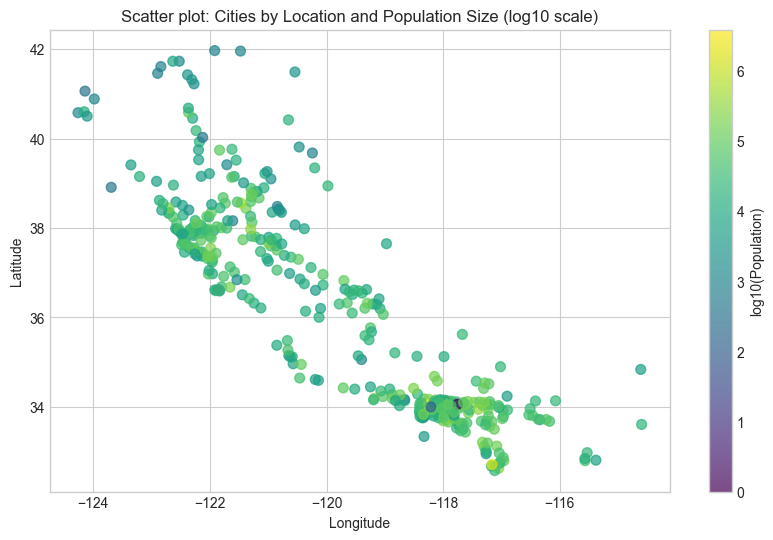

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Tính log10 của population_total
df["log_pop"] = np.log10(df["population_total"])

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    df["longd"], 
    df["latd"], 
    c=df["log_pop"], 
    cmap="viridis", 
    alpha=0.7,
    s=50
)

plt.colorbar(sc, label="log10(Population)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scatter plot: Cities by Location and Population Size (log10 scale)")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_5372\720285346.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


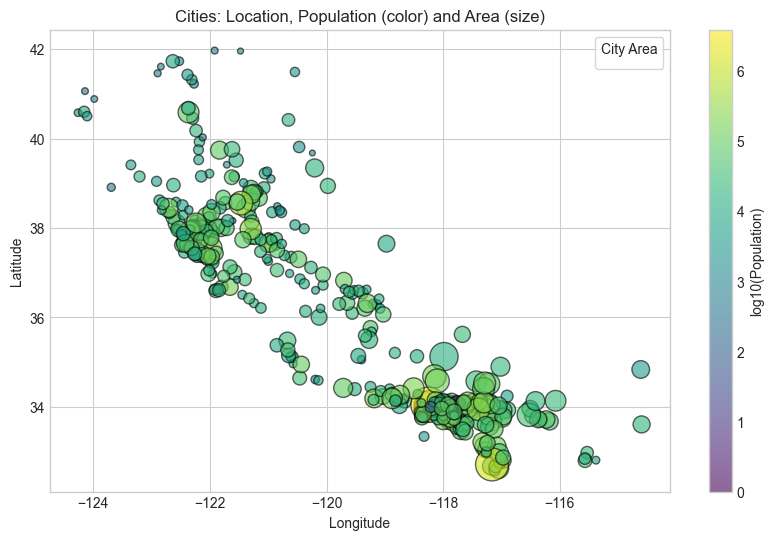

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Tính log10 của population_total
df["log_pop"] = np.log10(df["population_total"])

# Scale size để dễ hiển thị (vd: nhân 10 hoặc căn bậc 0.5)
size_factor = 18
sizes = np.sqrt(df['area_total_km2'].fillna(0)) * size_factor


plt.figure(figsize=(10, 6))
sc = plt.scatter(
    df["longd"],
    df["latd"],
    c=df["log_pop"],
    s=sizes,
    cmap="viridis",
    alpha=0.6,
    edgecolor="k"
)
plt.legend(
    title="City Area",
    scatterpoints=1,
    frameon=True,
    loc='upper right',
    fontsize=10
)
plt.colorbar(sc, label="log10(Population)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cities: Location, Population (color) and Area (size)")
plt.show()


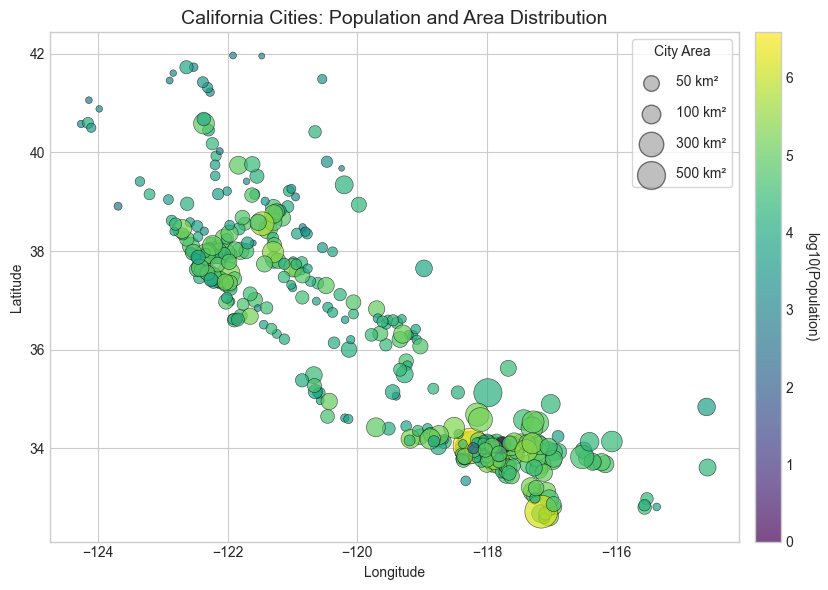

In [24]:
df['log_pop'] = np.log10(df['population_total'])

# scale size
size_factor = 18
sizes = np.sqrt(df['area_total_km2'].fillna(0)) * size_factor

# --- Vẽ ---
sns.set_style("whitegrid")
plt.figure(figsize=(9,6))

sc = plt.scatter(
    df['longd'],
    df['latd'],
    c=df['log_pop'],
    s=sizes,
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.4
)

# Colorbar
cbar = plt.colorbar(sc, pad=0.02)
cbar.set_label('log10(Population)', rotation=270, labelpad=18)

# --- Legend cho size ---
legend_areas = [50, 100, 300, 500]  # km² mẫu
legend_sizes = [np.sqrt(a) * size_factor for a in legend_areas]

# tạo các điểm giả chỉ để làm legend
handles = [
    plt.scatter([], [], c='gray', alpha=0.5, s=s, edgecolors='k')
    for s in legend_sizes
]
labels = [f"{a} km²" for a in legend_areas]

plt.legend(
    handles,
    labels,
    title="City Area",
    scatterpoints=1,
    frameon=True,
    loc='upper right',
    labelspacing=1.2,
    fontsize=10
)

# Labels, title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Cities: Population and Area Distribution", fontsize=14)

plt.tight_layout()
plt.show()


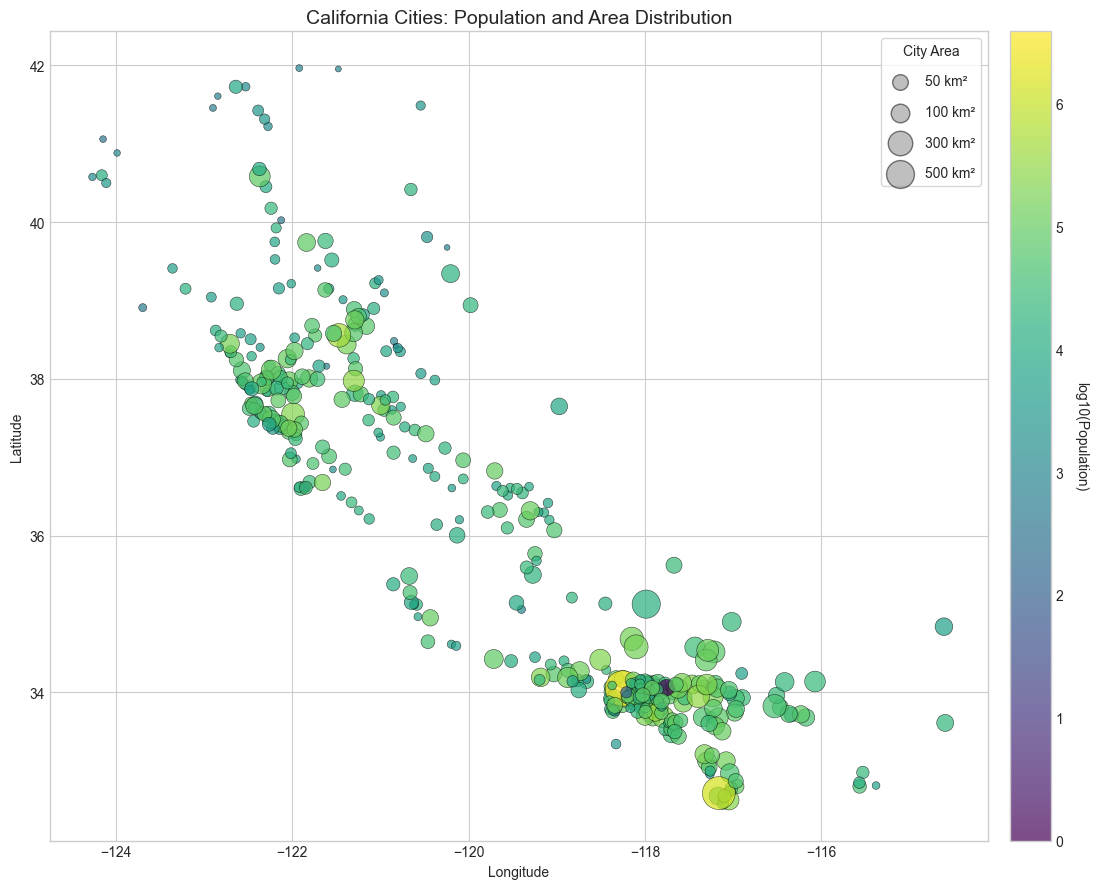

In [25]:
fig, ax = plt.subplots(figsize=(12, 9))

sc = ax.scatter(
    df['longd'],
    df['latd'],
    c=df['log_pop'],
    s=sizes,
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.4
)

# Colorbar gắn với figure
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('log10(Population)', rotation=270, labelpad=18)

# Legend cho size
legend_areas = [50, 100, 300, 500]  # km² mẫu
legend_sizes = [np.sqrt(a) * size_factor for a in legend_areas]

handles = [
    ax.scatter([], [], c='gray', alpha=0.5, s=s, edgecolors='k')
    for s in legend_sizes
]
labels = [f"{a} km²" for a in legend_areas]

ax.legend(
    handles,
    labels,
    title="City Area",
    scatterpoints=1,
    frameon=True,
    loc='upper right',
    labelspacing=1.2,
    fontsize=10
)

# Labels, title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("California Cities: Population and Area Distribution", fontsize=14)

fig.tight_layout()
plt.show()

In [29]:
x = np.linspace(0,5,30)

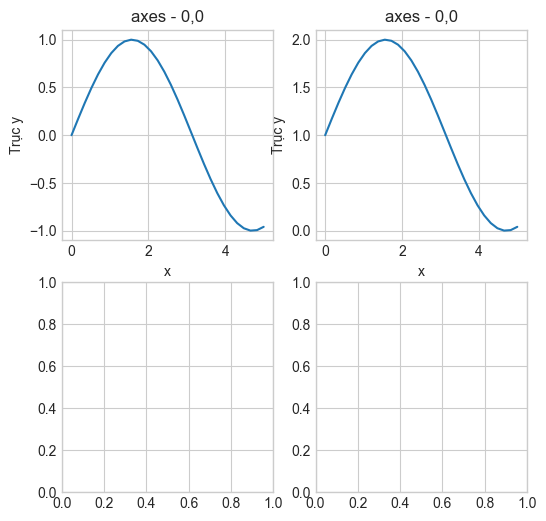

In [35]:
fig, axes = plt.subplots(2,2,figsize= (6,6))
axes[0,0].plot(x,np.sin(x))
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('Trục y')
axes[0,0].set_title("axes - 0,0")

axes[0,1].plot(x,1+ np.sin(x))
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('Trục y')
axes[0,1].set_title("axes - 0,0")

plt.show()

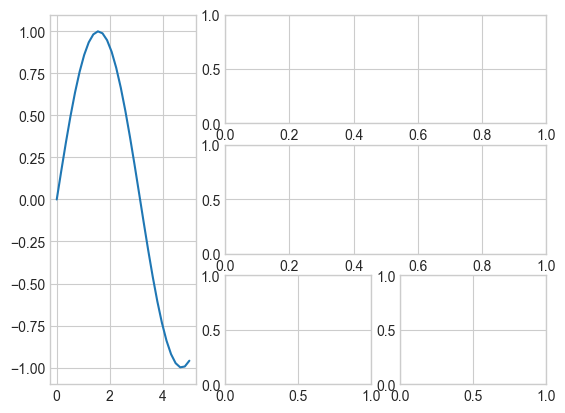

In [39]:
fig, axes = plt.subplot_mosaic([['a','c','c'],
                                ['a','b','b'],
                                ["a",'e','f']])
axes['a'].plot(x, np.sin(x));

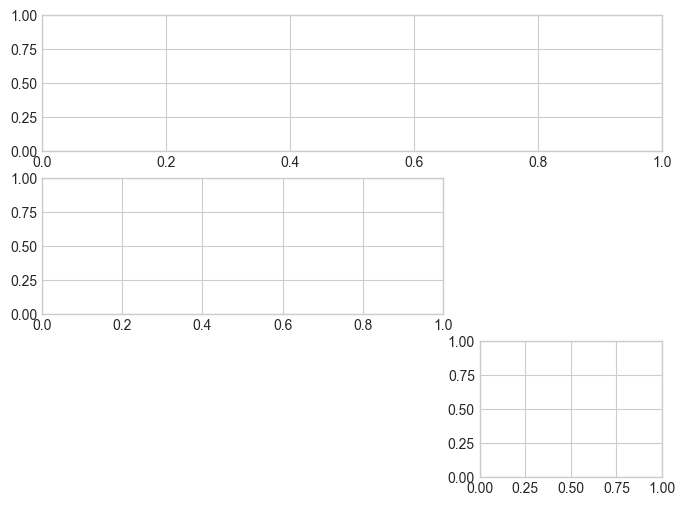

In [43]:
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(3, 3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :-1])
ax3 = fig.add_subplot(gs[2,2])

In [44]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


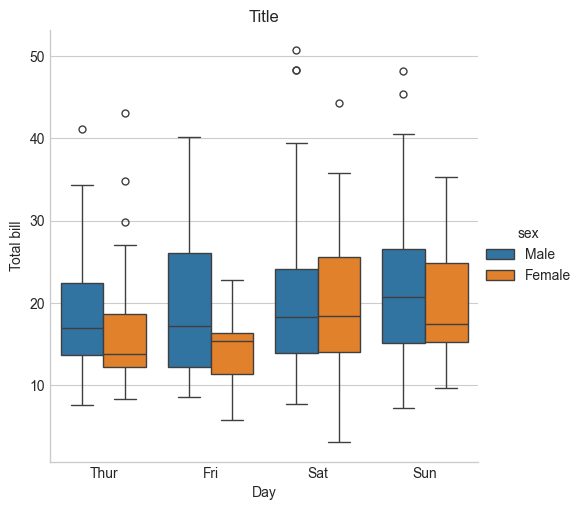

In [58]:
g = sns.catplot(data = tips,
            x = 'day',
            y='total_bill', kind = 'box', 
            hue = 'sex')
plt.title("Title")
g.set_axis_labels('Day', "Total bill");